In [1]:
import sys
# Add your lenscarf site-packages to the path
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

sys.path.append('/users/odarwish/abacusutils/')

from abacusnbody.data.read_abacus import read_asdf

import numpy as np

from abacusnbody.analysis.tsc import tsc_parallel

import matplotlib.pyplot as plt

from abacusnbody.analysis.power_spectrum import calc_power, calc_pk_from_deltak, get_k_mu_edges
from abacusnbody.analysis import power_spectrum as ps

from scipy.fft import rfftn, irfftn

import astropy

from classy import Class

import yaml

In [2]:
import numpy as np
import numba

@numba.njit(parallel=True)
def calc_power_mu0_x_axis(delta_k, BoxSize, k_bin_edges = np.logspace(np.log10(1e-3), np.log10(0.5), 200), delta_k2 = None):
    """
    Compute the μ=0 power spectrum (perpendicular to x-axis) from a 3D Fourier field
    
    Parameters
    ----------
    delta_k : array_like
        Complex 3D Fourier field of shape (n1d, n1d, n1d//2+1)
    BoxSize : float
        Physical size of the simulation box
    k_bin_edges : array_like
        Edges of the k bins for binning the power spectrum
        
    Returns
    -------
    k_values : ndarray
        Mean k values in each bin
    power : ndarray
        Power spectrum for modes perpendicular to x-axis (μ=0)
    nmodes : ndarray
        Number of modes in each bin
    """
    if delta_k2 is None:
        delta_k2 = delta_k
        
    # Get dimensions
    n1d = delta_k.shape[0]
    middle = n1d // 2
    kzlen = n1d // 2 + 1
    
    # Fundamental mode
    kF = 2.0 * np.pi / BoxSize
    
    # Set up arrays for results
    Nk = len(k_bin_edges) - 1
    k_values = np.zeros(Nk, dtype=np.float64)
    power = np.zeros(Nk, dtype=np.float64)
    nmodes = np.zeros(Nk, dtype=np.int64)
    
    # Convert bin edges to grid units
    kedges = np.zeros_like(k_bin_edges)
    for i in range(len(k_bin_edges)):
        kedges[i] = k_bin_edges[i] / kF
    
    # Loop over all independent modes in the Fourier grid
    for kxx in numba.prange(n1d):
        # Convert array index to k-space value
        kx = kxx - n1d if kxx > middle else kxx
        
        # For μ=0 with x-axis as line of sight, we need kx=0
        if kx != 0:
            continue
            
        for kyy in range(n1d):
            ky = kyy - n1d if kyy > middle else kyy
            
            for kzz in range(kzlen):
                kz = kzz  # kz is always positive due to rfft
                
                # Handle symmetry planes
                if kz == 0 or (kz == middle and n1d % 2 == 0):
                    if ky < 0:
                        continue
                    elif ky == 0 or (ky == middle and n1d % 2 == 0):
                        if kz < 0:
                            continue
                
                # Compute |k| of the mode for binning
                k_perp = np.sqrt(ky*ky + kz*kz)
                
                # Find the bin for this k value
                bin_idx = -1
                for b in range(Nk):
                    if k_perp >= kedges[b] and k_perp < kedges[b+1]:
                        bin_idx = b
                        break
                
                if bin_idx >= 0:
                    # Compute the power
                    #mode_power = np.abs(delta_k[kxx, kyy, kzz])**2
                    mode_power = np.real(delta_k[kxx, kyy, kzz] * np.conj(delta_k2[kxx, kyy, kzz]))
                    
                    # Account for complex conjugate modes
                    mode_count = 1 if (kz == 0 or (kz == middle and n1d % 2 == 0)) else 2
                    
                    # Add to the bin
                    nmodes[bin_idx] += mode_count
                    power[bin_idx] += mode_power * mode_count
                    k_values[bin_idx] += k_perp * kF * mode_count
    
    # Normalize the results
    for i in range(Nk):
        if nmodes[i] > 0:
            power[i] = power[i] / nmodes[i] * BoxSize**3  # Proper units
            k_values[i] = k_values[i] / nmodes[i]
    
    return k_values, power#, nmodes

In [3]:
from abacusnbody.analysis.power_spectrum import calc_power
from abacusnbody.data import read_abacus
from pathlib import Path
from astropy.io import ascii

In [4]:
scratch = "/users/odarwish/scratch/ABACUS/abacus_out/AbacusSummit_base_c000_ph000/z0.500/galaxies/"

In [5]:
z = 0.5

In [6]:
nome = scratch+"LRGs.dat"
LRG = ascii.read(nome)

nome = scratch+"ELGs.dat"
ELG = ascii.read(nome)

In [7]:
LRG['x'].size

7489072

In [8]:
N_lrg = LRG['x'].size
N_elg = ELG['x'].size
N_lrg, N_elg

(7489072, 10526353)

In [9]:
box = 2000
V = box**3
n_lrg = N_lrg/V
n_elg = N_elg/V
shot_lrg = 1/n_lrg
shot_elg = 1/n_elg

In [10]:
print(n_lrg*1e4, n_elg*1e4)

9.36134 13.15794125


In [11]:
box = 2000
nthread = 256
ngrid = 576#*2

In [12]:
interlaced = True
compensated = True
paste = 'TSC'

In [13]:
with open('config_abacus.yaml', 'r') as f:
    config = yaml.safe_load(f)
gen_nl_power = np.loadtxt(config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(config['power_spectrum']['linear'])

In [14]:
from abacusnbody.analysis import tsc
pos = np.vstack([LRG['x'], LRG['y'], LRG['z']]).T
delta_LRG = tsc.tsc_parallel(pos+box/2, ngrid, box, nthread=nthread)
delta_LRG /= np.mean(delta_LRG, dtype=np.float64)
delta_LRG -= 1.

/users/odarwish/abacusutils/abacusnbody/analysis/tsc.py:146: UserWarning: pos.dtype=float64 instead of np.float32. float32 is recommended for performance.
  warnings.warn(


In [15]:
pos = np.vstack([ELG['x'], ELG['y'], ELG['z']]).T
delta_ELG = tsc.tsc_parallel(pos+box/2, ngrid, box, nthread=nthread)
delta_ELG /= np.mean(delta_ELG, dtype=np.float64)
delta_ELG -= 1.

/users/odarwish/abacusutils/abacusnbody/analysis/tsc.py:146: UserWarning: pos.dtype=float64 instead of np.float32. float32 is recommended for performance.
  warnings.warn(


In [16]:
from abacusnbody.metadata import get_meta
from abacusnbody.hod.zcv.ic_fields import load_dens

D_ratio = 59.91148545808563

sim_name = config['sim_params']["sim_name"]
ic_dir = "/users/odarwish/scratch/ABACUS/ic/"
ic = load_dens(ic_dir, sim_name, ngrid)*D_ratio
ic_fft = rfftn(ic, overwrite_x=False, workers=nthread)
ic_fft /= ic.size
ic_fft = ic_fft.astype(np.complex64)

In [17]:
#delta_shifted = tsc.tsc_parallel(pos['pos']+box/2, ngrid, box, nthread=nthread)
#delta_shifted /= np.mean(delta_shifted, dtype=np.float64)
#delta_shifted -= 1.

In [18]:
del pos

In [19]:
from scipy.fft import rfftn, irfftn, fftfreq, rfftfreq
def get_kgrid(N):
    return 2 * np.pi * np.stack(
        np.meshgrid(
            fftfreq(N, d=box/N), fftfreq(N, d=box/N), rfftfreq(N, d=box/N),
            indexing='ij',
            )
        )

In [20]:
kgrid = get_kgrid(delta_ELG.shape[0])
print(kgrid.shape)
kmag = (kgrid**2).sum(axis=0)**0.5
print(kmag.shape)

(3, 576, 576, 289)
(576, 576, 289)


In [21]:
field_fft_ELG = rfftn(delta_ELG, overwrite_x=False, workers=nthread)
field_fft_ELG *= 1 / delta_ELG.size


field_fft_LRG = rfftn(delta_LRG, overwrite_x=False, workers=nthread)
field_fft_LRG *= 1 / delta_LRG.size

In [22]:
output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

In [23]:
W = ps.get_W_compensated(box, ngrid, paste, interlaced)
f = (
    W[:, np.newaxis, np.newaxis]
    * W[np.newaxis, :, np.newaxis]
    * W[np.newaxis, np.newaxis, : (ngrid // 2 + 1)]
)

In [24]:
import rec_utils as utils

large_scale_bins = np.logspace(np.log10(1e-3), np.log10(0.05), 10)
small_scale_bins = np.logspace(np.log10(0.1), np.log10(1), 80)
k_bin_edges = np.unique(np.concatenate([large_scale_bins, small_scale_bins]))

k_values, power_elg = utils.calc_power_mu0_x_axis(
            field_fft_ELG/f,     # Your FFT field
            BoxSize=box,   # Box size
            k_bin_edges = k_bin_edges
        )

k_values, power_lrg = utils.calc_power_mu0_x_axis(
            field_fft_LRG/f,     # Your FFT field
            BoxSize=box,   # Box size
            k_bin_edges = k_bin_edges
        )

k_values, power_lrg_elg_cross = utils.calc_power_mu0_x_axis(
            field_fft_LRG/f,     # Your FFT field
            BoxSize=box,   # Box size
            k_bin_edges = k_bin_edges,
            delta_k2 = field_fft_ELG/f
        )


k_values, power_elg_cross = utils.calc_power_mu0_x_axis(
            field_fft_ELG/f,     # Your FFT field
            BoxSize=box,   # Box size
            k_bin_edges = k_bin_edges,
            delta_k2 = ic_fft
        )

k_values, power_lrg_cross = utils.calc_power_mu0_x_axis(
            field_fft_LRG/f,     # Your FFT field
            BoxSize=box,   # Box size
            k_bin_edges = k_bin_edges,
            delta_k2 = ic_fft
        )


k_values, power_linear_matter = utils.calc_power_mu0_x_axis(
            ic_fft,     # Your FFT field
            BoxSize=box,   # Box size
            k_bin_edges = k_bin_edges
        )

In [25]:
from scipy import optimize
def get_b1_fit(power_data):
    kmin_, kmax_ = 5e-3, 0.02
    selected = (k_values > kmin_) & (k_values < kmax_)
    fraction = (power_data/power_linear_matter)[selected]
    
    def cost_function(b, data):
        """Sum of squared residuals for a constant bias model"""
        return np.sum((data - b)**2)
    
    
    initial_guess = [1.0]  # Initial guess for the bias
    result = optimize.minimize(
        cost_function,
        initial_guess,
        args=(fraction,),
        method='BFGS'  # You can try different methods
    )
    
    b_optimize = result.x[0]

    return b_optimize

b1_lrg = get_b1_fit(power_lrg_cross)
b1_elg = get_b1_fit(power_elg_cross)

/tmp/ipykernel_16016/2243207157.py:5: RuntimeWarning: invalid value encountered in divide
  fraction = (power_data/power_linear_matter)[selected]


In [26]:
b1_lrg

1.3250108285257707

In [27]:
b1_lrg

1.3250108285257707

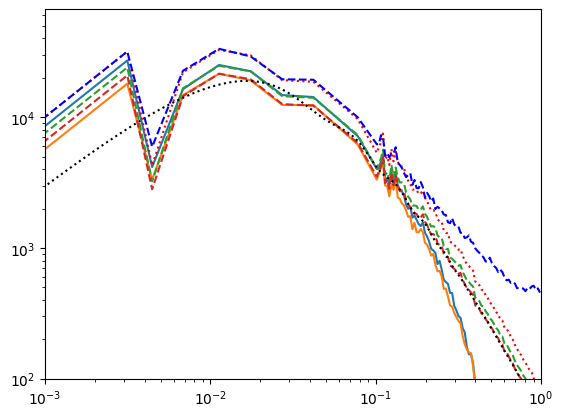

In [28]:

plt.plot(k_values, power_elg_cross)

plt.loglog(k_values, power_lrg_cross)

plt.plot(k_values, power_linear_matter*b1_elg, ls = "--")

plt.plot(k_values, power_linear_matter*b1_lrg, ls = "--")

plt.loglog(gen_power[:,0], gen_power[:,1]*b1_lrg, ls=':', c='k')


plt.loglog(k_values, power_linear_matter*b1_lrg*b1_elg, ls=':', c='r')
plt.loglog(k_values, power_lrg_elg_cross, ls='--', c='b')

plt.ylim(1e2)
plt.xlim(1e-3, 1)
plt.show()

Text(0, 0.5, 'P')

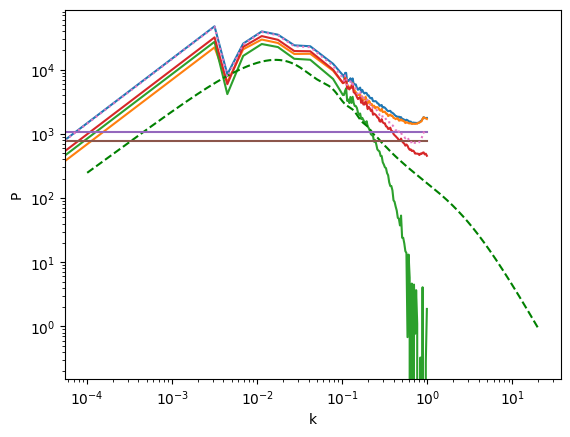

In [30]:
plt.loglog(k_values, power_elg)
plt.loglog(k_values, power_lrg)

plt.plot(k_values, power_elg_cross)

plt.loglog(k_values, power_lrg_elg_cross)

#index = 0
#plt.loglog(power_delta['k_avg'][:, index], power_delta['power'][:, index], ls = "--", c = "k")


plt.loglog(gen_nl_power[:,0], gen_nl_power[:,1], ls='--', c='g')

plt.plot(k_values, np.ones_like(k_values)*shot_lrg)
plt.plot(k_values, np.ones_like(k_values)*shot_elg)

plt.loglog(k_values, power_elg-shot_elg, ls = ":")


plt.xlabel("k")
plt.ylabel("P")
#plt.xlim(kmin_vol)
#plt.ylim(100)

In [31]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

sim_params = config['sim_params']
HOD_params = config['HOD_params']
clustering_params = config['clustering_params']
zcv_params = config['zcv_params']

In [32]:
from abacusnbody.hod.abacus_hod import AbacusHOD
newBall = AbacusHOD(sim_params, HOD_params, clustering_params)

In [33]:
mock_dict = {}
mock_dict['LRG'] = LRG

In [34]:
nobj = mock_dict['LRG']['mass'].size
print('number of galaxies', nobj)

number of galaxies 7489072


In [42]:
def calc(mock_dict, power_total, shot):
    load_presaved = False
    # Run zcv on the power spectrum multipoles
    zcv_dict = newBall.apply_zcv(mock_dict, config, load_presaved=load_presaved)
    #print(zcv_dict.keys())
    #for key in zcv_dict.keys():
    #    if 'Pk' in key:
    #        print(key, zcv_dict[key][:10])
    #        print('-----------------')
    
    sim_name = config['sim_params']['sim_name']
    z = config['sim_params']['z_mock']
    ztarget = z
    meta = get_meta(sim_name, redshift=z)
    Lbox = meta['BoxSize']
    z_ic = meta['InitialRedshift']
    Ndim = int(meta['ppd'])
    
    Dz = meta['GrowthTable']
    
    pk = meta['CLASS_power_spectrum']
    kk  = pk['k (h/Mpc)']
    
    zpk = meta['ZD_Pk_file_redshift']  # 1.0
    pk = meta['CLASS_power_spectrum']
    k  = pk['k (h/Mpc)']
    input_pk = pk['P (Mpc/h)^3']
    pkk = input_pk * (Dz[ztarget] / Dz[zpk])**2
    
    k_max = 20.0
    n_points = 2000
    k_min = 1e-4
    
    cosmo = {}
    cosmo['output'] = 'mPk'
    cosmo['P_k_max_h/Mpc'] = k_max
    int(sim_name.split('ph')[-1])
    for k in (
            'H0',
            'omega_b',
            'omega_cdm',
            'omega_ncdm',
            'N_ncdm',
            'N_ur',
            'n_s',
            'A_s',
            'alpha_s',
            #'wa', 'w0',
    ):
        cosmo[k] = meta[k]
    
    import pyccl as ccl
    import pyccl.nl_pt as pt
    
    def omega_ncdm_to_mnu(omega_ncdm, h):
        # Approximate conversion based on standard neutrino properties
        # This is a simplified conversion - actual relation depends on T_ncdm
        return omega_ncdm * 93.14 / h**2  # Result in eV
    
    As = cosmo['A_s']
    ns = cosmo['n_s']
    h = cosmo['H0']/100
    Omega_b = cosmo['omega_b']/h**2
    Omega_c = cosmo['omega_cdm']/h**2
    mnu = 0.13
    
    cosmo = ccl.Cosmology(Omega_c = Omega_c, Omega_b = Omega_b, h = h, A_s = As, n_s = ns, m_nu = mnu)
    
    a = 1/(1+127)
    growthf = ccl.background.growth_factor(cosmo, a)
    
    
    a1, a2 = 1, -17/21
    b_1 = 1+zcv_dict['bias'][0]
    b_2 = zcv_dict['bias'][1]
    b_s = zcv_dict['bias'][2]

    b_2_eul =  2*(a1 + a2)*zcv_dict['bias'][0]+ a2*zcv_dict['bias'][1]
    b_s_eul = -2/7*zcv_dict['bias'][0]+zcv_dict['bias'][2]

    out_biases = {}
    out_biases["b_1"] = b_1
    out_biases["b_2"] = b_2
    out_biases["b_s"] = b_s
    out_biases["b_2_eul"] = b_2_eul
    out_biases["b_s_eul"] = b_s_eul
    
    ptt_g = pt.PTNumberCountsTracer(b1=b_1, b2=b_2, bs=b_s)
    ptt_g_eulerian = pt.PTNumberCountsTracer(b1=b_1, b2=b_2_eul, bs=b_s_eul)
    ptt_m = pt.PTMatterTracer()
    
    a = 1/(1+sim_params['z_mock'])
    
    ptc = pt.EulerianPTCalculator(with_NC=True, with_IA=False,
                          log10k_min=-6, log10k_max=2, nk_per_decade=30)
    ptc.update_ingredients(cosmo)
    
    pk_gg = ptc.get_biased_pk2d(ptt_g)
    pk_gg_eulerian = ptc.get_biased_pk2d(ptt_g_eulerian)
    
    # Galaxies x matter
    pk_gm = ptc.get_biased_pk2d(ptt_g, tracer2=ptt_m)
    pk_mm = ptc.get_biased_pk2d(ptt_m)
    
    
    plt.loglog(k_values, power_total, label = "Measured total gg")
    
    plt.loglog(gen_nl_power[:,0], (1+zcv_dict['bias'][0])**2*gen_nl_power[:,1]+zcv_dict['bias'][-1], ls='--', c='g', label = "Linear model gg")
    
    plt.loglog(k_values, power_total-shot, ls = ":", label = "gg with no shot noise")

    plt.plot(k_values, pk_gg(k_values*h, a, cosmo)*h**3, color = "purple", ls = "-")
    plt.plot(k_values, pk_gg(k_values*h, a, cosmo)*h**3, color = "black", ls = "--", label = "Model gg using pyccl")

    
    
    
    #plt.loglog(kk, pk_mm(kk*h, a, cosmo)*h**3, color = "red")
    #plt.loglog(kk, pkk, lw = 2, ls = "--")
    plt.loglog(gen_power[:,0], gen_power[:,1], ls=':', c='k')
    
    
    plt.xlabel("k")
    plt.ylabel("P")
    #plt.xlim(kmin_vol)
    plt.ylim(100)
    plt.xlim(1e-3, 1)
    plt.legend()
    plt.show()

    return out_biases, b_1**2*gen_nl_power[:,1]+shot

D =  58.8985672746677
min/max tracer pos 6.1035156e-05 1999.9999 (7489072, 3)
Computing auto-correlation of tracer
Computing cross-correlation of tracer and  1cb
Computing cross-correlation of tracer and  delta
Computing cross-correlation of tracer and  delta2
Computing cross-correlation of tracer and  tidal2
zeros in the measured power spectra =  0 1440 288
zeros in the measured power spectra =  0 1440 288
bias [ 1.          0.38353917  1.48342289 -1.88628721  0.          0.00562453]
Warning, you selected a extrap_low that is greater than k_min. Therefore no extrapolation will be done.


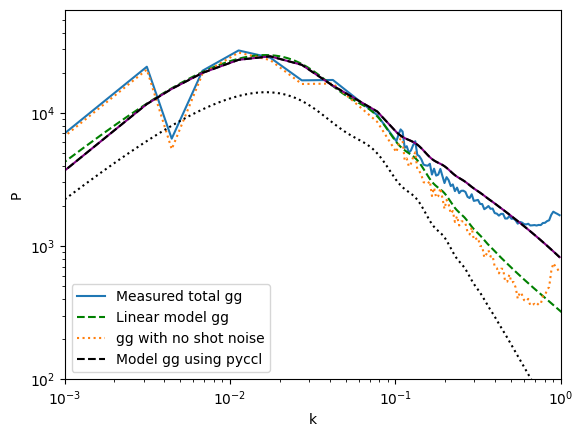

In [43]:
mock_dict = {}
mock_dict['LRG'] = LRG
out_biases_lrg, ptot_nlin_lrg = calc(mock_dict, power_lrg, shot_lrg)

D =  58.8985672746677
min/max tracer pos 0.0 1999.9999 (10526353, 3)
Computing auto-correlation of tracer
Computing cross-correlation of tracer and  1cb
Computing cross-correlation of tracer and  delta
Computing cross-correlation of tracer and  delta2
Computing cross-correlation of tracer and  tidal2
zeros in the measured power spectra =  0 1440 288
zeros in the measured power spectra =  0 1440 288
bias [ 1.          0.58893324  1.50796232 -1.43233783  0.          0.00330907]
Warning, you selected a extrap_low that is greater than k_min. Therefore no extrapolation will be done.


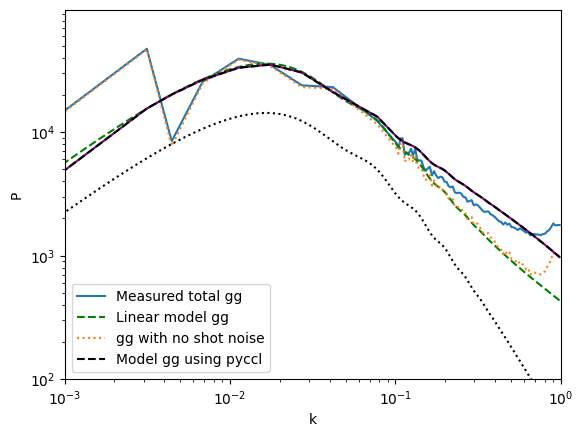

In [44]:
mock_dict = {}
mock_dict['LRG'] = ELG
out_biases_elg, ptot_nlin_elg = calc(mock_dict, power_elg, shot_elg)

In [45]:
#do reconstructions

In [46]:
import rec_utils as utils, rec

In [47]:
with open('config_abacus.yaml', 'r') as f:
    config_rec = yaml.safe_load(f)

In [48]:
gen_power = np.loadtxt(config_rec['power_spectrum']['linear'])
Plin_interp = np.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config_rec['k_range']['kmin'], config_rec['k_range']['kmax']


kr_config = config_rec['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

ps_config = config_rec['power_spectrum']

Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [107]:
kgrid, kmag = utils.get_kgrid_kmag(box, delta_ELG.shape[0])

In [97]:
output_config = config_rec['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config_rec['name']
out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()
out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()

In [118]:
import qeutils
import jax

import numpy as np
import sympy as sp
import sympy2jax
ptot_nlin_lrg
n_elg

def do_stuff(delta_field, out_biases, ptot_nlin, nbar):


    Ptot_interp = np.interp(kmag, gen_nl_power[:,0], ptot_nlin)

    knl, pnl = np.loadtxt(ps_config['nonlinear']).T
    kl, pl = np.loadtxt(ps_config['linear']).T
    
    interpolate_function = qeutils.get_interpolated(gen_nl_power[:,0], ptot_nlin)
    interpolate_function_lin = qeutils.get_interpolated(kl, pl)
    
    q1, q2, mu = sp.symbols('q1 q2 mu')
    
    def get_total_P():
        return jax.jit(lambda k: interpolate_function(k))
    
    nbar_A = n_elg
    nbar_B = n_elg
    
    P_AA = get_total_P()
    P_BB = get_total_P()
    P_AB = get_total_P() #jax.jit(lambda k: b10_A*b10_B*interpolate_function(k))
    P_linear = jax.jit(lambda k: interpolate_function_lin(k))
    
    
    sampling_config = config_rec['sampling']
    Nsamples_base = sampling_config['Nsamples_base']
    Fg_factor = 17/21
    estimator_configs = {
            'g': {
                'F': Fg_factor*q1/q1,
                'ca': 1., #Cg["g"](b1A=b10_A, b2A=b20_A, b1B=b10_B, bthetaA=0, bdeltathetaA=0, fX=0, bmrA=0, brA=0), #AB
                'cb': 1., #Cg["g"](b1A=b10_B, b2A=b20_B, b1B=b10_A, bthetaA=0, bdeltathetaA=0, fX=0, bmrA=0, brA=0) #BA
            },
            's': {
                'F': 0.5*(q2/q1+q1/q2)*mu,
                'ca': 1, #Cg["s"](b1A=b10_A, b2A=0, bs2A=0, b1B=b10_B, b2B=0, bs2B=0),
                'cb': 1 #Cg["s"](b1A=b10_B, b2A=0, bs2A=0, b1B=b10_A, b2B=0, bs2B=0)
            },
            't': {
                'F': (2./7.)*(mu**2.-1./3.),
                'ca': 1., #Cg["t"](b1A=b10_A, b2A=0, bs2A=bs2_A, b1B=b10_B, b2B=0, bs2B=0),
                'cb': 1. #Cg["t"](b1A=b10_B, b2A=0, bs2A=bs2_B, b1B=b10_A, b2B=0, bs2B=0)
            },
            'n': {
                'F': 0.5*mu*q2/q1,
                'ca': 1, #Cg["n"](1, 0, 0, 1, 0, 0),
                'cb': 0  #Cg["n"](1, 0, 0, 0, 0, 0)
            }
            }
    estimator_lam_jax = {key: sympy2jax.SymbolicModule(estimator_configs[key]['F']) for key in estimator_configs}
    f_jax = {key: qeutils.get_f(estimator_lam_jax[key], P_linear, estimator_configs[key]["ca"], estimator_configs[key]["cb"]) for key in estimator_lam_jax}
    
    
    out_normalization_AB = {}
    out_variance_AB = {}
    import itertools
    keys = ["g", "s", "t", "n"]
    keypairs = list(itertools.combinations_with_replacement(keys, 2))
    
    for keypair in keypairs:
        key1, key2 = keypair
        N_single_AB = qeutils.N_per_mode(f_jax[key1], f_jax[key2], P_AA, P_BB, kmin, kmax, Nsamples_base=Nsamples_base, gauss_filter=False)
        out_normalization_AB[tuple(keypair)] = qeutils.integrate(Ks, N_single_AB, batch_size=2)
        out_normalization_AB[(key2, key1)] = out_normalization_AB[tuple(keypair)]
    
        w_A = qeutils.get_w(f_jax[key1], P_AA, P_BB)
        w_B = qeutils.get_w(f_jax[key2], P_AA, P_BB)
    
        if key1 == key2:
            variance_single_AB = qeutils.variance_per_mode(w_A, w_B, P_AA, P_BB, P_AB, P_AB, kmin, kmax, Nsamples_base=Nsamples_base//20, gauss_filter = False)
            out_variance_AB[tuple(keypair)] = qeutils.integrate(Ks, variance_single_AB, batch_size=2)
            out_variance_AB[(key2, key1)] = out_variance_AB[tuple(keypair)]
    
    
    
    def plot(key, power, cross = False, biases_rec = {}):
        non_linear_pk_interp = np.interp(Ks, gen_nl_power[:,0], gen_nl_power[:,1])
        
        N = out_normalization_AB[(key, key)]**-1.
        v = out_variance_AB[(key, key)]
    
        if not cross:
            plt.plot(Ks, N, label = "Normalization Noise")
            plt.plot(Ks, N**2*v, label = "Variance", ls = "--")
        
        factor = 1/delta_ELG.size**2
        
        bias = 0
        kinds = ["s", "t", "g"]
        for kk in kinds:
            bias += (N*out_normalization_AB[(key, kk)])*biases_rec[kk]
    
        k, linear_pk = gen_power.T
        linear_pk_interp = np.interp(Ks, k, linear_pk)
        if cross:
            plt.loglog(Ks, abs(bias)*linear_pk_interp, ls = "--")
        else:
            plt.loglog(Ks, bias**2*linear_pk_interp+N, ls = "--")
        
        a, b = k_values, power*factor**(1+int(cross==False))
        b[0] = 0.
        b = b.astype(float)
        value = np.interp(Ks, a, b)*N**(1+int(cross==False))
        plt.loglog(Ks, abs(value), ls = "--", label = "Reconstruction", color = "black")
        
        #plt.ylim(1e-6, 1)
        plt.xlim(2e-3, 2e-1)
        
        plt.legend()
    
        plt.show()
    
    
    
    for key in keys:
        growth_rec = rec.get_rec(key, delta_field, box, kmin, kmax, Ptot_interp, Plin_interp)
        
        k_values, growth_power = calc_power_mu0_x_axis(
            growth_rec,     # Your FFT field
            BoxSize=box,   # Box size
        )
        k_values, growth_power_cross = calc_power_mu0_x_axis(
                    growth_rec,     # Your FFT field
                    BoxSize=box,   # Box size
                    delta_k2 = ic_fft.astype(np.complex128)
                )
        
        g = (out_biases['b_1']+Fg_factor*1/2*out_biases['b_2_eul'])*out_biases['b_1']
        s = out_biases['b_1']*out_biases['b_1']
        t = (out_biases['b_1']+7/2*out_biases['b_s_eul'])*out_biases['b_1']
        biases_rec = {"g": g, "s": s, "t": t}
        
        power = growth_power
        
        plt.title(key)
        plot(key, power, biases_rec = biases_rec)
        plt.title(key)
        plot(key, growth_power_cross, cross = True, biases_rec = biases_rec)

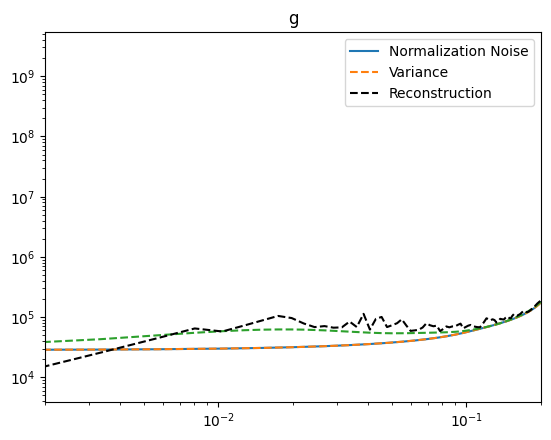

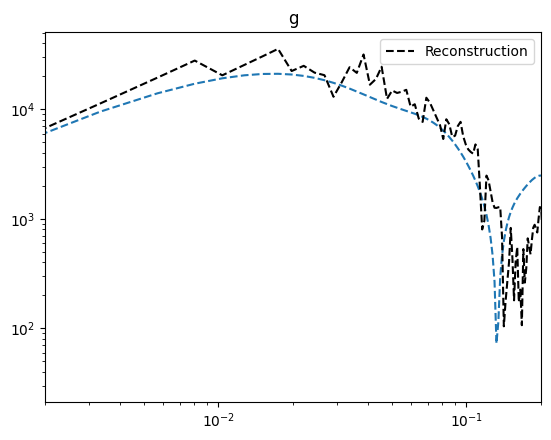

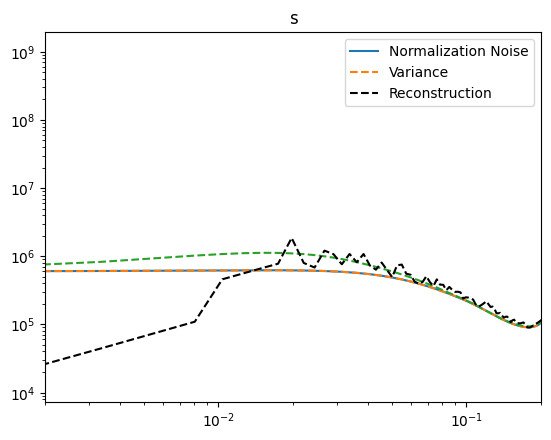

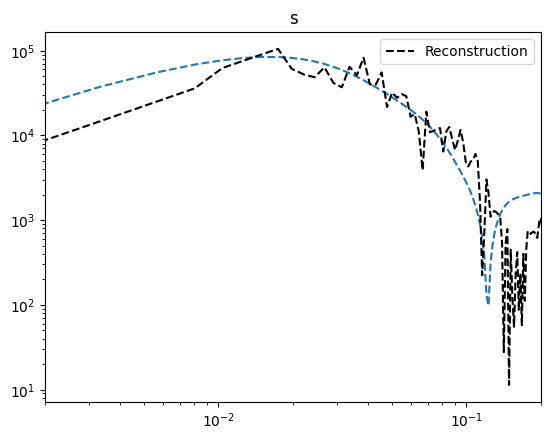

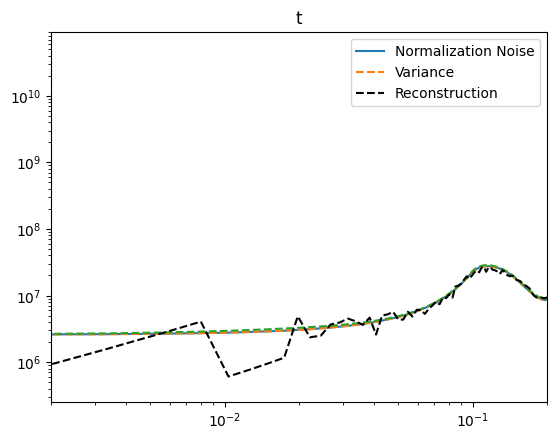

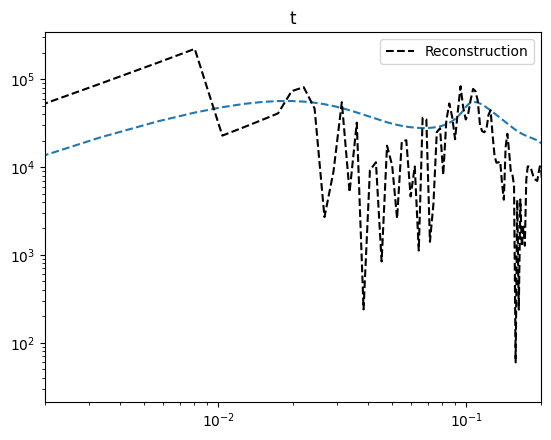

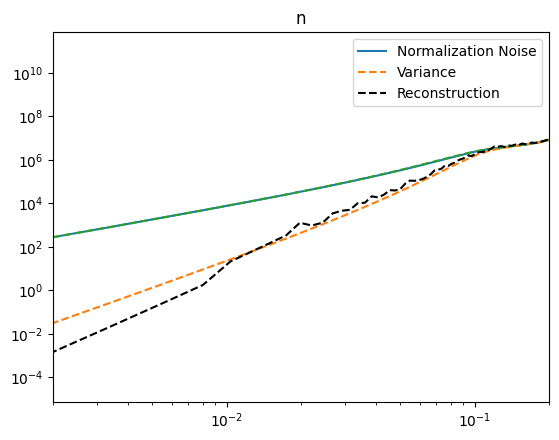

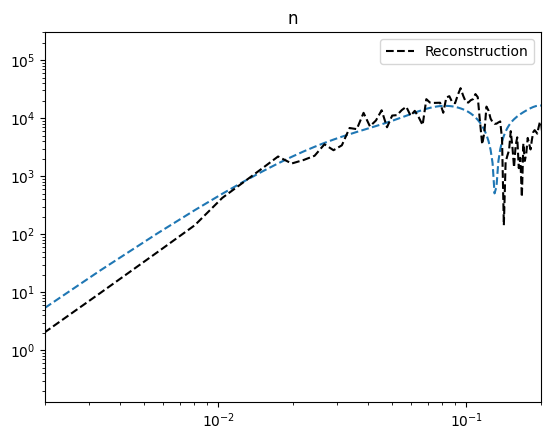

In [119]:
do_stuff(delta_ELG, out_biases_elg, ptot_nlin_elg, n_elg)

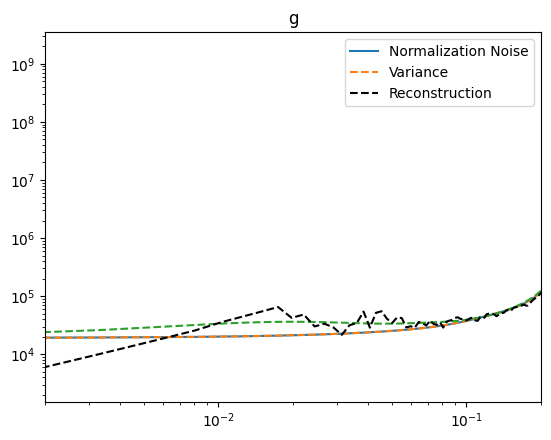

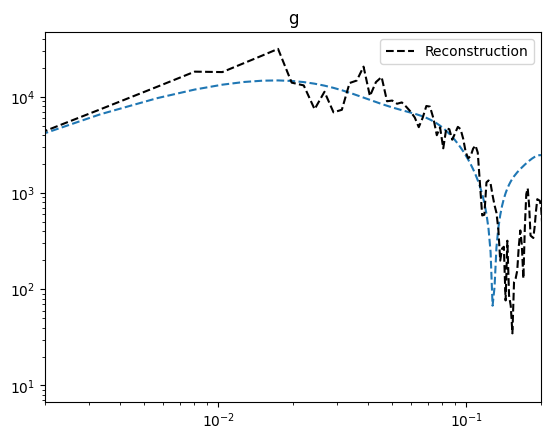

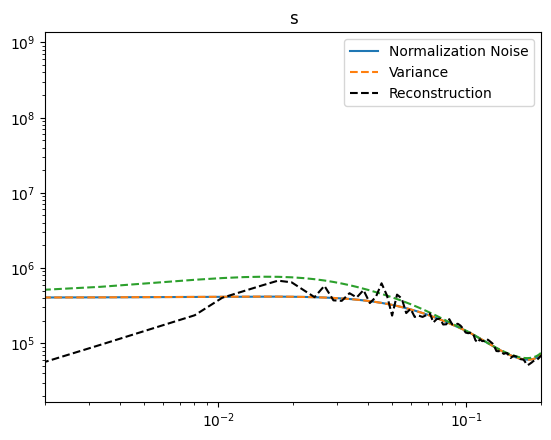

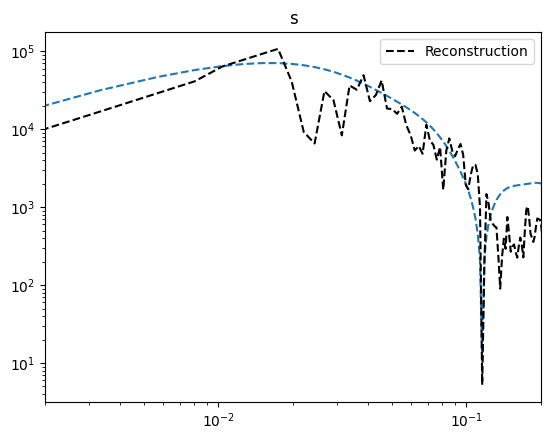

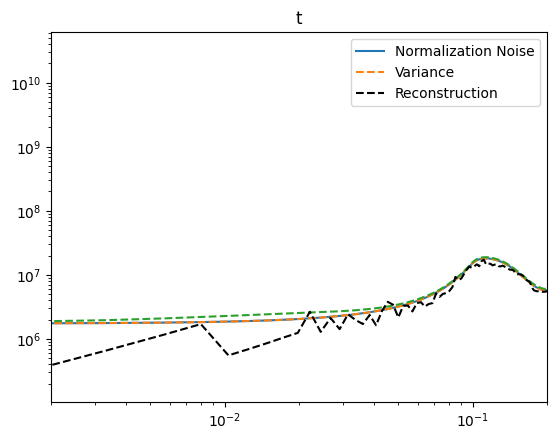

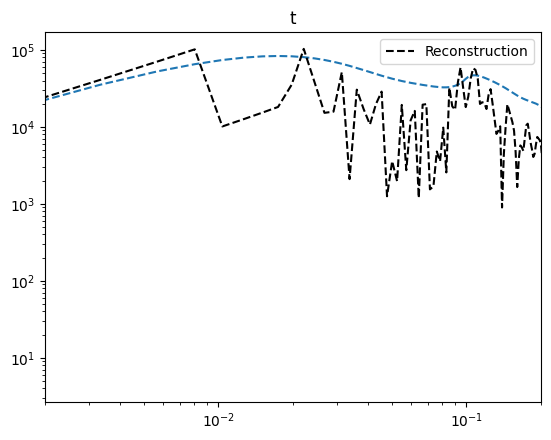

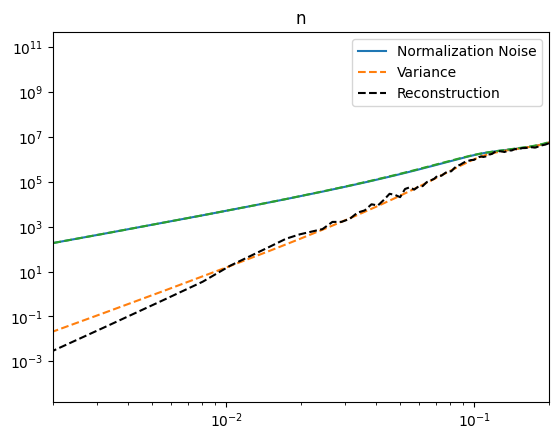

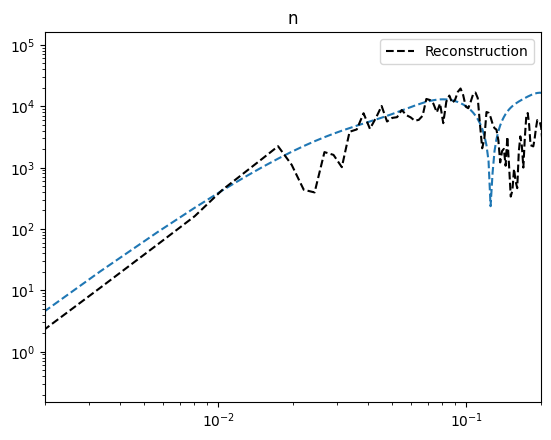

In [120]:
do_stuff(delta_LRG, out_biases_lrg, ptot_nlin_lrg, n_lrg)